# Cellular Automata Rule Weight Analysis

이 노트북은 Wolfram 셀룰러 오토마타(CA) 규칙을 시뮬레이션하고,
초기 활성 셀 개수(밀도)에 따른 확산 패턴을 선형 회귀로 분석합니다.

`weight_generate.ipynb`에서 계산하는 `weight[rule][initial]`
(= 60세대 시점 활성 셀 개수의 회귀 예측값) 이 어떻게 만들어지는지
시각적으로 보여주는 것이 목적입니다.

**2026-09-17 업데이트**: 기존 Julia 버전(GLM/Plots)을 Python으로 포팅했습니다.
Julia 환경의 GLM 패키지가 설치 불가능한 상태(32bit BLAS 빌드 문제)였고,
프로젝트의 다른 모든 코드가 Python이라 일관성을 위해 전환했습니다.
CA 시뮬레이션도 numpy 벡터 연산으로 다시 작성해 77개 규칙을 몇 초 안에 처리합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.facecolor"] = "white"


## 1. CA 규칙 정의 및 시뮬레이션

Wolfram 규칙 번호를 8비트 전이 테이블로 변환하고, 여러 시행(trial)을
numpy 배열 연산으로 한 번에 처리합니다 (경계는 항상 0으로 고정).

In [2]:
def rule_table(rule_number):
    """Wolfram 규칙 번호(0~255) -> 길이 8 전이 테이블.
    인덱스 = left*4 + center*2 + right."""
    binary_rep = format(rule_number, "08b")
    table = np.zeros(8, dtype=np.int64)
    for idx in range(8):
        table[idx] = int(binary_rep[7 - idx])
    return table


def simulate_batch(rule_number, init_num, n_trials, n_gens=400, grid_size=400, rng=None):
    """rule_number 규칙을, 초기 활성 셀 init_num개로 n_trials번 시뮬레이션해서
    세대별 평균 활성 셀 개수를 반환한다 (경계 고정 0, 동기 업데이트)."""
    rng = rng if rng is not None else np.random.default_rng()
    table = rule_table(rule_number)

    state = np.zeros((n_trials, grid_size), dtype=np.int64)
    for t in range(n_trials):
        idx = rng.choice(grid_size, size=init_num, replace=False)
        state[t, idx] = 1

    counts = np.zeros((n_trials, n_gens), dtype=np.float64)
    for g in range(n_gens):
        counts[:, g] = state.sum(axis=1)
        left, center, right = state[:, :-2], state[:, 1:-1], state[:, 2:]
        idx = left * 4 + center * 2 + right
        new_state = np.zeros_like(state)
        new_state[:, 1:-1] = table[idx]
        state = new_state

    return counts.mean(axis=0)  # shape (n_gens,)


## 2. 선형 회귀 유틸리티

`weight_generate.ipynb`와 동일하게, 평균 궤적에 단순 선형 회귀를 적합시켜
특정 세대(기본 60세대)에서의 예측값과 R²를 구합니다.

In [3]:
def fit_regression(x, y):
    """1차 선형회귀. (slope, intercept, r_squared) 반환."""
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
    return slope, intercept, r_squared


def predict_at(slope, intercept, x_value):
    return slope * x_value + intercept


## 3. 단일 규칙 상세 그림

초기 활성 셀 100/200/300개 조건에서 100회 평균 궤적과 회귀선을 함께 그립니다.
`skip_gens`로 초기 과도기를 회귀에서 제외할 수 있고, `show_prediction`으로
특정 세대의 예측값을 점으로 표시할 수 있습니다.

In [4]:
def rule_graph(rule_num, output_dir=OUTPUT_DIR, n_trials=100, n_gens=400,
               skip_gens=0, show_regression=True, show_r2=True,
               show_prediction=False, prediction_gen=60, show_ci=True,
               seed=0, save=True):
    initial_conditions = [100, 200, 300]
    colors = {100: "tab:blue", 200: "tab:green", 300: "tab:purple"}
    rng = np.random.default_rng(seed)

    fig, ax = plt.subplots(figsize=(8, 6))
    x_full = np.arange(n_gens)

    for init_num in initial_conditions:
        y = simulate_batch(rule_num, init_num, n_trials, n_gens=n_gens, rng=rng)

        x_reg = x_full[skip_gens:]
        y_reg = y[skip_gens:]
        slope, intercept, r2 = fit_regression(x_reg, y_reg)

        if skip_gens > 0:
            ax.plot(x_full[:skip_gens], y[:skip_gens], color="lightgray",
                    linestyle="--", linewidth=1.2)

        label = f"Initial {init_num}"
        if show_r2:
            label += f" (R\u00b2={r2:.3f})"
        if show_prediction:
            pred_val = predict_at(slope, intercept, prediction_gen)
            label += f" -> {pred_val:.1f} @gen{prediction_gen}"
        ax.plot(x_full[skip_gens:], y_reg, color=colors[init_num], linewidth=1.5, label=label)

        if show_regression:
            y_line = predict_at(slope, intercept, x_reg)
            ax.plot(x_reg, y_line, color="red", linewidth=2,
                    label="Regression line" if init_num == initial_conditions[0] else None)
            if show_ci:
                residual_std = np.std(y_reg - y_line)
                ax.fill_between(x_reg, y_line - residual_std, y_line + residual_std,
                                 color="red", alpha=0.15)

        if show_prediction:
            pred_val = predict_at(slope, intercept, prediction_gen)
            ax.plot([prediction_gen, prediction_gen], [0, pred_val], color="black",
                    linestyle="--", linewidth=1)
            ax.scatter([prediction_gen], [pred_val], color="black", zorder=5, s=40)

    title = f"Rule {rule_num}" + (f" (skip first {skip_gens} gens)" if skip_gens else "")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Number of 1s")
    ax.set_xlim(-3, n_gens)
    ax.set_ylim(-3, n_gens)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    if save:
        suffix = f"_skip{skip_gens}" if skip_gens else ""
        out_path = Path(output_dir) / f"Fig7_{rule_num}{suffix}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"저장 위치: {out_path}")

    plt.show()
    return fig


저장 위치: figures/Fig7_30.png


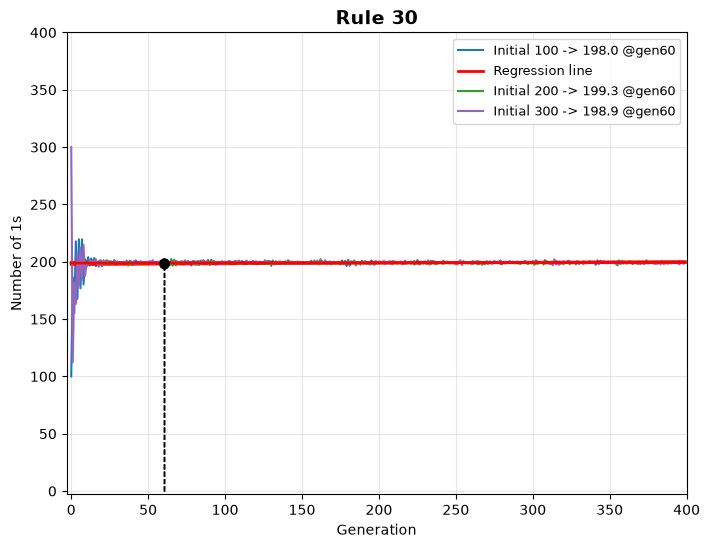

In [5]:
# 예시: Rule 30, 60세대 예측값 표시
rule_graph(30, show_prediction=True, prediction_gen=60, show_ci=False, show_r2=False);


## 4. CA 진화 히트맵

한 규칙이 시간에 따라 어떻게 패턴을 만들어가는지 시각화합니다.

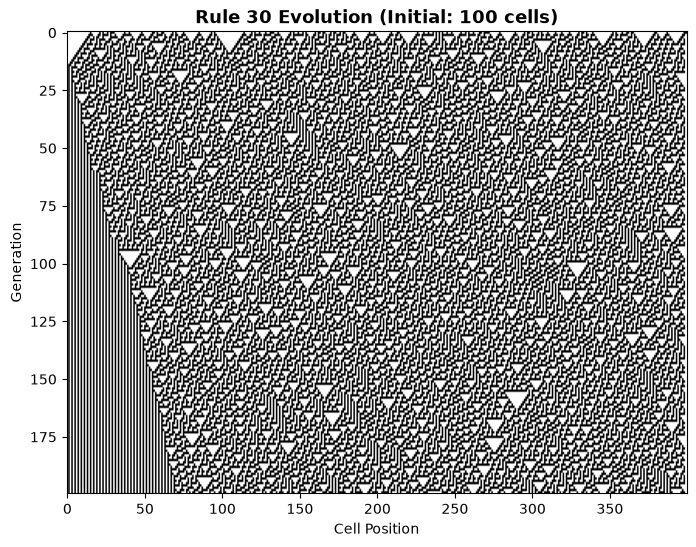

In [6]:
def visualize_evolution(rule_num, init_num, seed=42, num_gens=200, grid_size=400):
    rng = np.random.default_rng(seed)
    table = rule_table(rule_num)
    state = np.zeros(grid_size, dtype=np.int64)
    idx = rng.choice(grid_size, size=init_num, replace=False)
    state[idx] = 1

    evolution = np.zeros((num_gens, grid_size), dtype=np.int64)
    for g in range(num_gens):
        evolution[g] = state
        left, center, right = state[:-2], state[1:-1], state[2:]
        new_state = np.zeros_like(state)
        new_state[1:-1] = table[left * 4 + center * 2 + right]
        state = new_state

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(evolution, cmap="binary", aspect="auto")
    ax.set_xlabel("Cell Position")
    ax.set_ylabel("Generation")
    ax.set_title(f"Rule {rule_num} Evolution (Initial: {init_num} cells)", fontsize=13, fontweight="bold")
    plt.show()
    return evolution


_ = visualize_evolution(30, 100, seed=42)


## 5. 여러 규칙 일괄 분석 (배치 그리드)

CA_77에서 사용하는 77개 규칙을 하나의 그림으로 한눈에 비교합니다.
규칙마다 initial 100/200/300 궤적을 작은 서브플롯으로 그리고,
전체 그림 하나에 격자로 배치합니다 (개별 PNG 77장 대신 요약 그림 1장).

In [7]:
# CA_77에서 사용한 77개 규칙 (오름차순)
selected_rules = [2, 4, 6, 8, 10, 12, 14, 18, 22, 24, 26, 28, 30, 34, 36, 38, 40, 42, 44, 46,
                  50, 54, 56, 58, 60, 62, 72, 74, 76, 78, 90, 94, 104, 106, 108, 110, 122, 126,
                  130, 132, 134, 136, 138, 140, 142, 146, 150, 152, 154, 156, 158, 160, 162, 164,
                  166, 168, 170, 172, 174, 178, 182, 184, 186, 188, 190, 200, 202, 204, 206, 218,
                  222, 232, 234, 236, 238, 250, 254]
print(f"규칙 개수: {len(selected_rules)}")


규칙 개수: 77


저장 위치: figures/batch_grid_all_rules.png


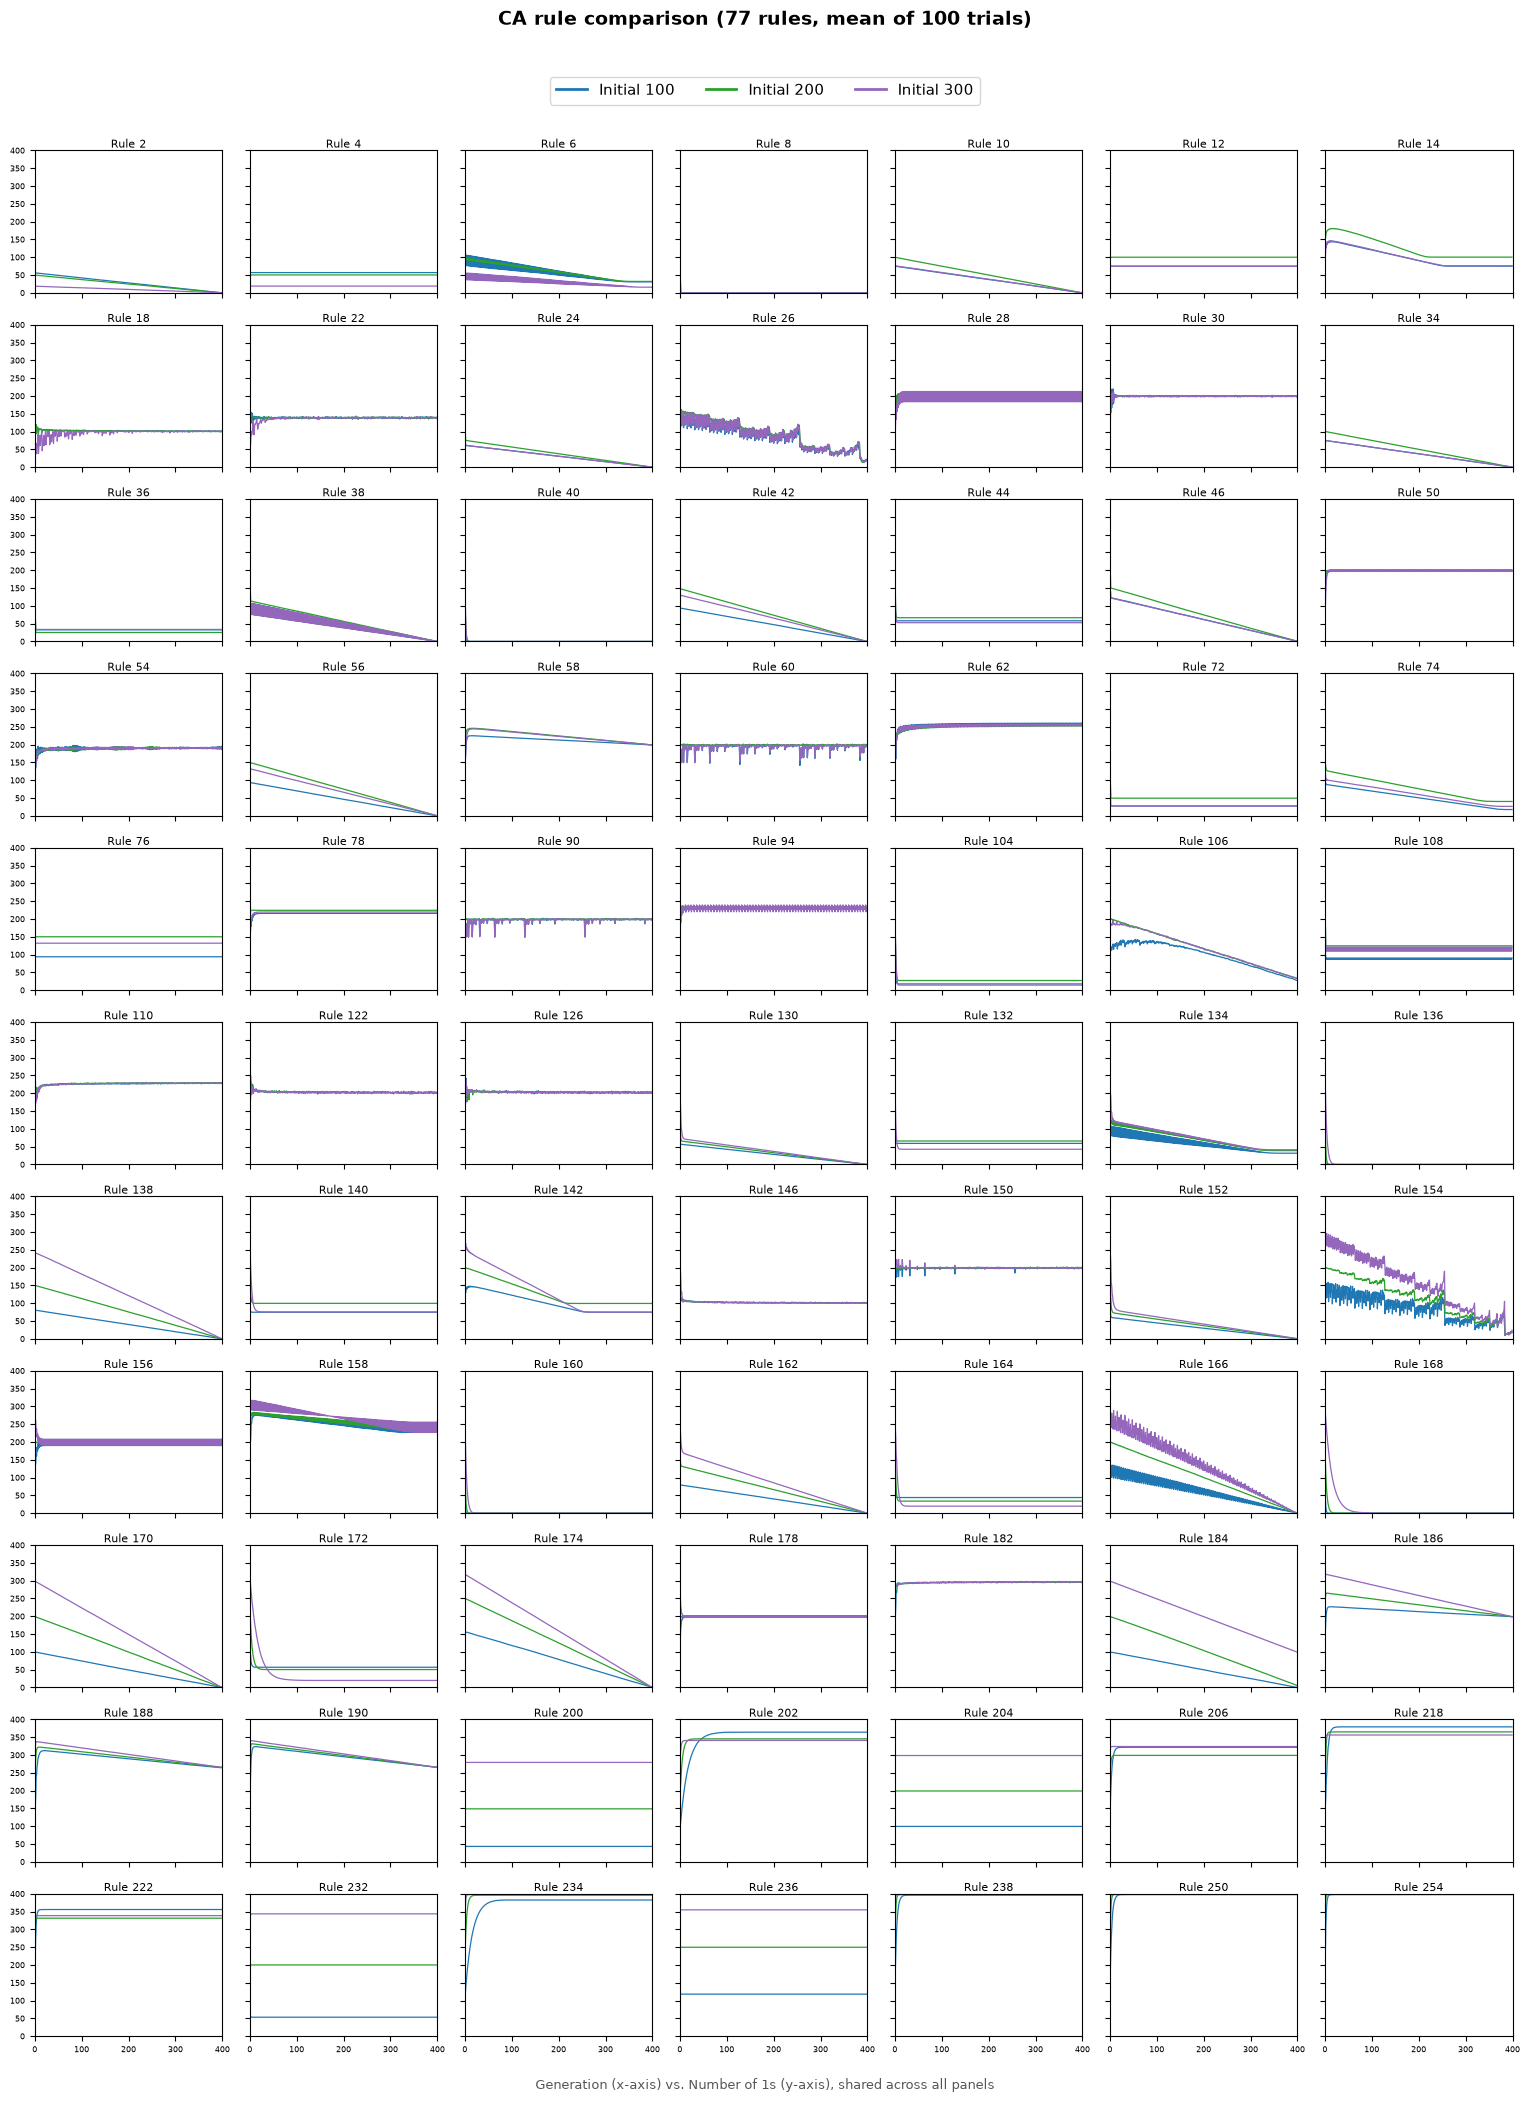

In [8]:
def rule_batch_grid(rules, initial_conditions=(100, 200, 300), n_trials=100, n_gens=400,
                     ncols=7, seed=0, output_path=OUTPUT_DIR / "batch_grid_all_rules.png"):
    colors = {100: "tab:blue", 200: "tab:green", 300: "tab:purple"}
    nrows = int(np.ceil(len(rules) / ncols))
    rng = np.random.default_rng(seed)

    fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 1.8 * nrows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    x_full = np.arange(n_gens)
    for i, rule_num in enumerate(rules):
        ax = axes[i // ncols, i % ncols]
        for init_num in initial_conditions:
            y = simulate_batch(rule_num, init_num, n_trials, n_gens=n_gens, rng=rng)
            ax.plot(x_full, y, color=colors[init_num], linewidth=0.9)
        ax.set_title(f"Rule {rule_num}", fontsize=8, pad=2)
        ax.set_xlim(0, n_gens)
        ax.set_ylim(0, n_gens)
        ax.tick_params(labelsize=6)

    # 남는 빈 서브플롯 숨기기
    for j in range(len(rules), nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")

    handles = [plt.Line2D([0], [0], color=colors[k], lw=2, label=f"Initial {k}") for k in initial_conditions]
    fig.legend(handles=handles, loc="upper center", ncol=len(initial_conditions),
               bbox_to_anchor=(0.5, 1.01), fontsize=11)
    fig.suptitle(f"CA rule comparison ({len(rules)} rules, mean of {n_trials} trials)",
                 fontsize=14, fontweight="bold", y=1.04)
    fig.text(0.5, -0.01, "Generation (x-axis) vs. Number of 1s (y-axis), shared across all panels",
              ha="center", fontsize=9, color="#555555")

    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"저장 위치: {output_path}")
    plt.show()
    return fig


rule_batch_grid(selected_rules);
